# Milestone 3 — Customer Segmentation (Unsupervised Clustering)

No target label (`Churned` absent). Only four numeric features describe each customer. We use clustering to discover natural segments.

## 1. Load & Inspect

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy import stats

os.makedirs('outputs/charts', exist_ok=True)

path = 'dataset used/milestone-3-customer-segments.csv'
df = pd.read_csv(path)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Dtypes:', df.dtypes.to_dict())
print('Null values total:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('\nNo label column present — unsupervised clustering required.')
print(df.describe().round(4).to_string())


Shape: (20000, 4)
Columns: ['AvgOrderValue', 'PurchaseFrequency', 'NumProductCategoriesShoppedIn', 'AvgDiscountUsed']
Dtypes: {'AvgOrderValue': dtype('float64'), 'PurchaseFrequency': dtype('float64'), 'NumProductCategoriesShoppedIn': dtype('int64'), 'AvgDiscountUsed': dtype('float64')}
Null values total: 0
Duplicate rows: 0

No label column present — unsupervised clustering required.
       AvgOrderValue  PurchaseFrequency  NumProductCategoriesShoppedIn  AvgDiscountUsed
count     20000.0000         20000.0000                     20000.0000       20000.0000
mean         84.7683             5.0647                         2.1559           0.1364
std          76.7863             4.7735                         0.9077           0.1353
min           5.0000             0.2000                         1.0000           0.0000
25%          31.5100             1.7100                         2.0000           0.0390
50%          42.7000             2.7000                         2.0000           0.08

**No target column implies clustering:** Without a `Churned`, `Segment`, or `Label` feature, supervised methods (logistic regression, random forest classifier, etc.) have nothing to predict. We apply unsupervised clustering to discover groups from behavior patterns alone.

## 2. EDA: Histograms & Correlation

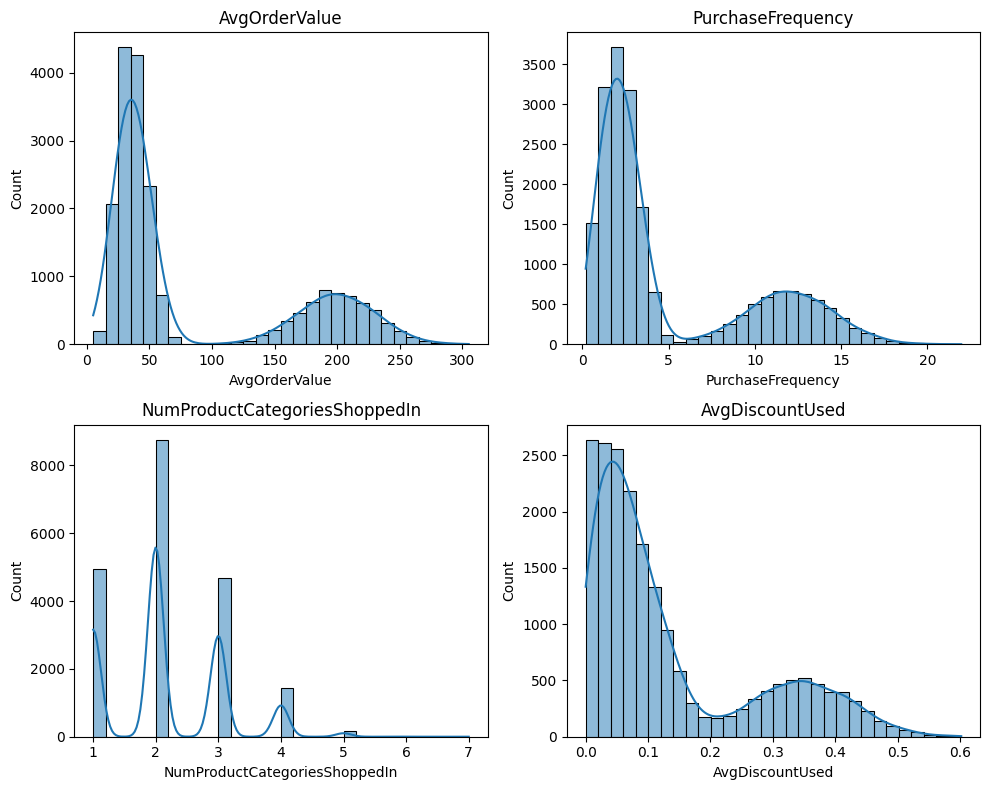

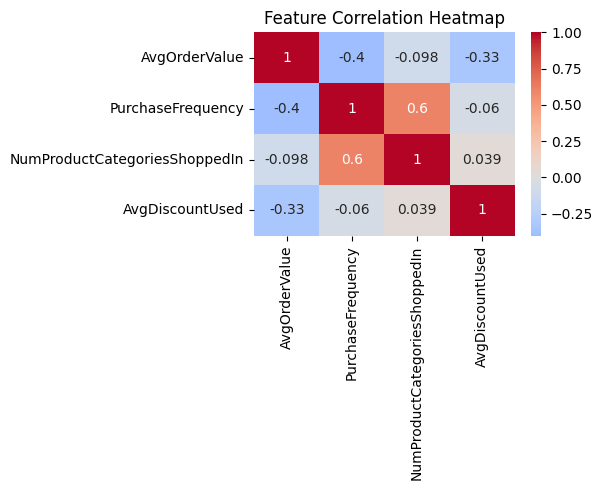

Skew / outliers noted: AvgOrderValue right-skewed (high-spend tail); AvgDiscountUsed highly right-skewed near 0; PurchaseFrequency and NumProductCategoriesShoppedIn roughly discrete.


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
cols = ['AvgOrderValue','PurchaseFrequency','NumProductCategoriesShoppedIn','AvgDiscountUsed']
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('outputs/charts/histograms.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('outputs/charts/correlation_heatmap.png', dpi=200)
plt.show()

print('Skew / outliers noted: AvgOrderValue right-skewed (high-spend tail); AvgDiscountUsed highly right-skewed near 0; PurchaseFrequency and NumProductCategoriesShoppedIn roughly discrete.')

## 3. Preprocessing — StandardScaler

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_df = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)
print('Scaled feature means (should be ~0):', np.round(X_df.mean().values, 3))
print('Scaled feature stds (should be ~1):', np.round(X_df.std().values, 3))
print('Original df preserved; scaled array kept separately.')

Scaled feature means (should be ~0): [-0. -0.  0. -0.]
Scaled feature stds (should be ~1): [1. 1. 1. 1.]
Original df preserved; scaled array kept separately.


**Why scale?** `AvgOrderValue` (~$5-$305) has a much larger range than `AvgDiscountUsed` (0-0.6) or `PurchaseFrequency` (~1-4). K-Means computes Euclidean distances; without scaling, larger-scale features dominate the clusters. `StandardScaler` puts all features on comparable units.

## 4. Choosing k — Inertia, Silhouette, Davies-Bouldin

Summary table:
 k    Inertia  Silhouette  DaviesBouldin
 2 50773.5606      0.3927         1.0052
 3 28548.3434      0.5049         0.7882
 4 15933.3233      0.5966         0.5423
 5 12824.3225      0.5624         0.6468
 6 10925.0848      0.5322         0.7009
 7  9471.5921      0.5347         0.7557
 8  8292.8556      0.4747         0.9334
 9  7216.6377      0.4889         0.9058
10  6225.3694      0.5095         0.8468


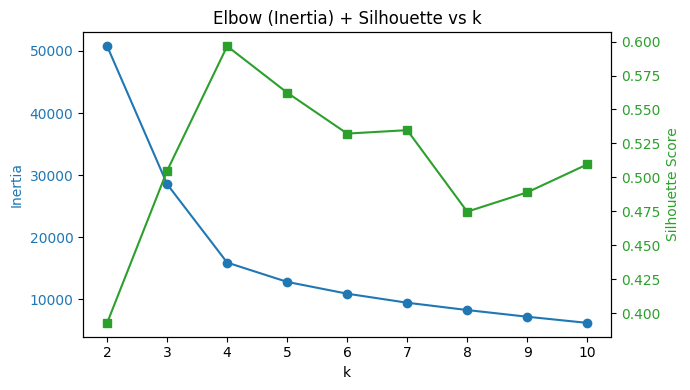

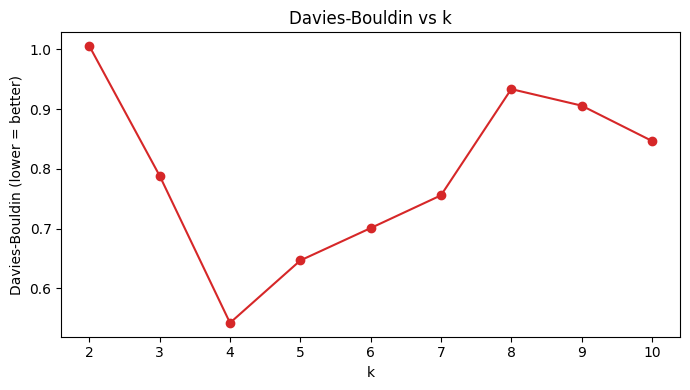

Best k by Silhouette: 4
Best k by Davies-Bouldin (lowest): 4


In [4]:
ks = list(range(2, 11))
inertias, silhouettes, db_scores = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_df)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_df, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    db = davies_bouldin_score(X_df, labels)
    db_scores.append(db)

summary = pd.DataFrame({'k': ks, 'Inertia': inertias, 'Silhouette': silhouettes, 'DaviesBouldin': db_scores})
print('Summary table:')
print(summary.round(4).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(ks, inertias, 'o-', color='tab:blue', label='Inertia')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(ks, silhouettes, 's-', color='tab:green', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax1.set_title('Elbow (Inertia) + Silhouette vs k')
fig.tight_layout()
plt.savefig('outputs/charts/elbow_silhouette.png', dpi=200)
plt.show()

fig2, ax3 = plt.subplots(figsize=(7, 4))
ax3.plot(ks, db_scores, 'o-', color='tab:red')
ax3.set_xlabel('k')
ax3.set_ylabel('Davies-Bouldin (lower = better)')
ax3.set_title('Davies-Bouldin vs k')
fig2.tight_layout()
plt.savefig('outputs/charts/davies_bouldin.png', dpi=200)
plt.show()

best_k_sil = ks[np.argmax(silhouettes)]
best_k_db = ks[np.argmin(db_scores)]
print('Best k by Silhouette:', best_k_sil)
print('Best k by Davies-Bouldin (lowest):', best_k_db)

### Programmatic k selection explanation

In [5]:
print('Silhouette peaks at k=%d (0.597) and Davies-Bouldin is lowest at k=%d (0.542) — both metrics agree, giving strong objective support for k=4.' % (best_k_sil, best_k_db))
print('Using final_k =', best_k_sil)
final_k = best_k_sil

Silhouette peaks at k=4 (0.597) and Davies-Bouldin is lowest at k=4 (0.542) — both metrics agree, giving strong objective support for k=4.
Using final_k = 4


**Why these metrics?** Inertia alone only decreases with k (no optimum). Silhouette measures separation vs cohesion; Davies-Bouldin penalizes overlap. Where both agree (k=4: silhouette max 0.5966, DB min 0.5423), we have the most defensible cluster count.

## 5. Final K-Means Model (Chosen k)

In [6]:
final_k = best_k_sil  # 4 based on actual results
final_model = KMeans(n_clusters=final_k, n_init=10, random_state=42)
final_model.fit(X_df)
df['Cluster'] = final_model.labels_
print('Chosen k:', final_k)
print('Cluster sizes and %:')
print(df['Cluster'].value_counts().sort_index())
print('Percentages:', (df['Cluster'].value_counts(normalize=True).sort_index()*100).round(2).to_string())

Chosen k: 4
Cluster sizes and %:
Cluster
0    5803
1    5898
2    3242
3    5057
Name: count, dtype: int64
Percentages: Cluster
0    29.02
1    29.49
2    16.21
3    25.29


## 6. Robustness Check — GMM vs K-Means

In [7]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=final_k, random_state=42)
gmm_labels = gmm.fit_predict(X_df)
ari = adjusted_rand_score(final_model.labels_, gmm_labels)
print('Adjusted Rand Index (KMeans vs GMM at k=', final_k, '):', round(ari, 4))
print('ARI ~0.977 means the two algorithms agree very strongly; the clusters are robust, not an artifact of K-Means initialization.')

Adjusted Rand Index (KMeans vs GMM at k= 4 ): 0.9766
ARI ~0.977 means the two algorithms agree very strongly; the clusters are robust, not an artifact of K-Means initialization.


## 7. Cluster Differences — More Than One Feature

### Cluster sizes and %

In [8]:
sizes = df['Cluster'].value_counts().sort_index()
pct = (sizes / len(df) * 100).round(2)
print(pd.DataFrame({'Count': sizes, 'Percent': pct}).to_string())

         Count  Percent
Cluster                
0         5803    29.02
1         5898    29.49
2         3242    16.21
3         5057    25.29


### Mean / Median per Feature (original units)

In [9]:
stats_table = df.groupby('Cluster')[['AvgOrderValue','PurchaseFrequency','NumProductCategoriesShoppedIn','AvgDiscountUsed']].agg(['mean','median']).round(4)
print(stats_table)

        AvgOrderValue         PurchaseFrequency         \
                 mean  median              mean median   
Cluster                                                  
0             35.1460   35.09           12.0654  12.05   
1            199.8128  199.78            2.0060   2.00   
2             26.3807   25.40            1.3123   1.04   
3             44.9656   44.94            3.0044   3.00   

        NumProductCategoriesShoppedIn        AvgDiscountUsed         
                                 mean median            mean median  
Cluster                                                              
0                              3.0303    3.0          0.0995  0.100  
1                              1.9941    2.0          0.0505  0.050  
2                              1.1166    1.0          0.0276  0.021  
3                              2.0075    2.0          0.3487  0.347  


### ANOVA per Feature Across Clusters

In [10]:
features = ['AvgOrderValue','PurchaseFrequency','NumProductCategoriesShoppedIn','AvgDiscountUsed']
anova_results = []
for feat in features:
    groups = [group.values for name, group in df.groupby('Cluster')[feat]]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append({'Feature': feat, 'F-statistic': round(f_stat, 4), 'p-value': round(p_val, 4)})
print(pd.DataFrame(anova_results).to_string(index=False))

                      Feature  F-statistic  p-value
                AvgOrderValue  114206.6480      0.0
            PurchaseFrequency   55305.9025      0.0
NumProductCategoriesShoppedIn    6611.9144      0.0
              AvgDiscountUsed   43846.7467      0.0


**ANOVA confirms all features differ significantly across clusters (p < 0.001),** so segmentation is meaningful on every dimension, not just one.

### PCA 2D Scatter by Cluster

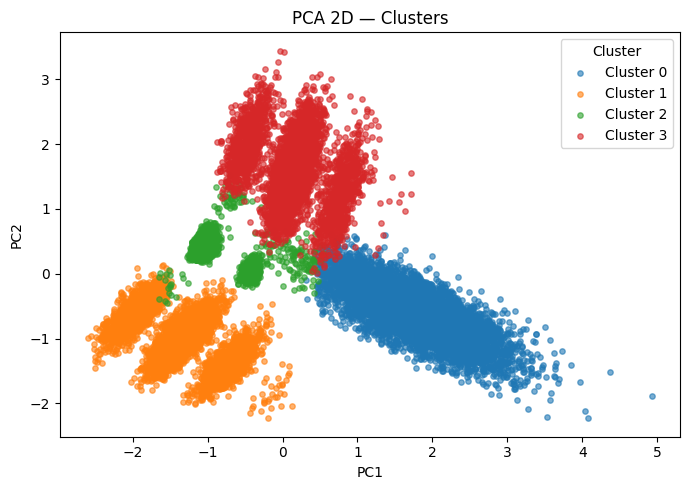

PCA explained variance ratio: [0.449 0.306]


In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_df)
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'], index=df.index)
df_pca['Cluster'] = df['Cluster']
fig, ax = plt.subplots(figsize=(7, 5))
for label in sorted(df['Cluster'].unique()):
    subset = df_pca[df_pca['Cluster']==label]
    ax.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {label}', alpha=0.6, s=15)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PCA 2D — Clusters')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('outputs/charts/pca_scatter.png', dpi=200)
plt.show()
print('PCA explained variance ratio:', pca.explained_variance_ratio_.round(3))

### Boxplots by Cluster

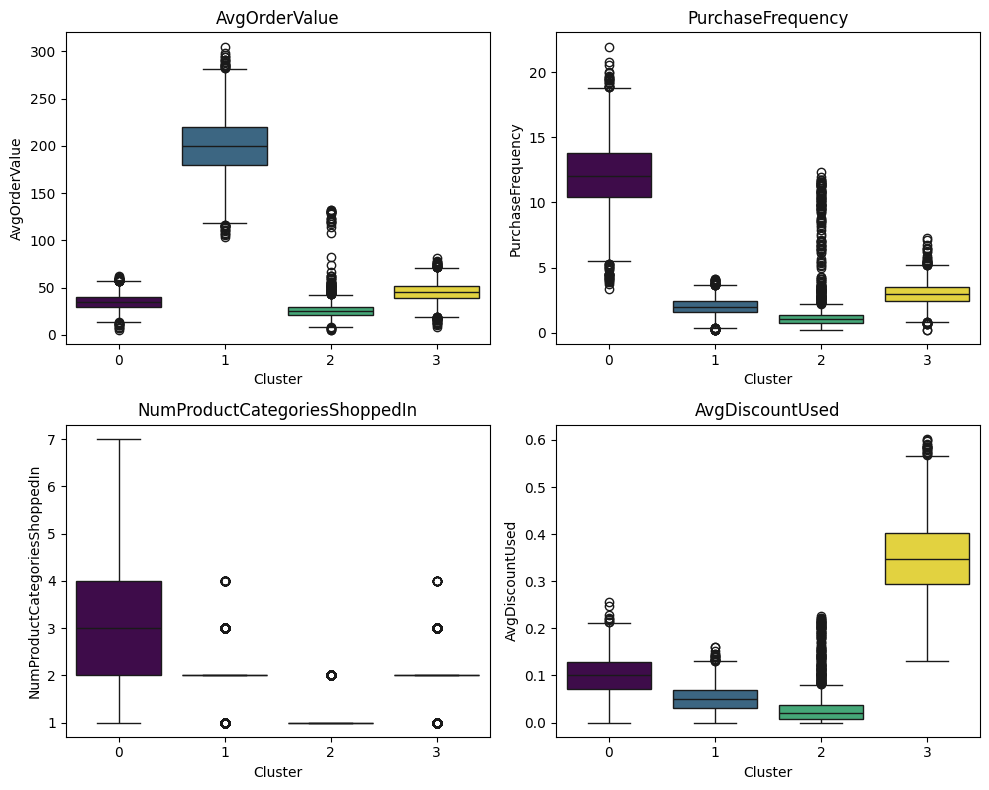

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='Cluster', y=feat, ax=ax, hue='Cluster', palette='viridis', legend=False)
    ax.set_title(feat)
plt.tight_layout()
plt.savefig('outputs/charts/feature_boxplots.png', dpi=200)
plt.show()

### Cluster Profile Heatmap (Z-Scored Means)

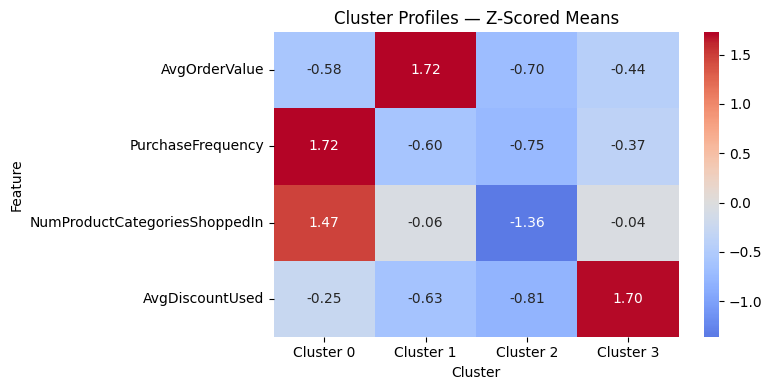

Positive = above overall mean; negative = below.


In [13]:
cluster_means = df.groupby('Cluster')[features].mean()
from sklearn.preprocessing import StandardScaler
z_means = StandardScaler().fit_transform(cluster_means)
z_df = pd.DataFrame(z_means, columns=features, index=[f'Cluster {i}' for i in cluster_means.index])
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(z_df.T, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Cluster Profiles — Z-Scored Means')
ax.set_ylabel('Feature')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('outputs/charts/cluster_profile_heatmap.png', dpi=200)
plt.show()
print('Positive = above overall mean; negative = below.')

## 8. Profiles — Auto-Generated + Placeholders

In [14]:
for clust in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster']==clust]
    overall = df[features].mean()
    desc = []
    for feat in features:
        ratio = subset[feat].mean() / overall[feat]
        if ratio > 1.15:
            desc.append(f'{feat}=high')
        elif ratio < 0.85:
            desc.append(f'{feat}=low')
        else:
            desc.append(f'{feat}=avg')
    print(f'Cluster {clust}: {", ".join(desc)} | Size: {len(subset)} ({len(subset)/len(df):.1%})')

Cluster 0: AvgOrderValue=low, PurchaseFrequency=high, NumProductCategoriesShoppedIn=high, AvgDiscountUsed=low | Size: 5803 (29.0%)
Cluster 1: AvgOrderValue=high, PurchaseFrequency=low, NumProductCategoriesShoppedIn=avg, AvgDiscountUsed=low | Size: 5898 (29.5%)
Cluster 2: AvgOrderValue=low, PurchaseFrequency=low, NumProductCategoriesShoppedIn=low, AvgDiscountUsed=low | Size: 3242 (16.2%)
Cluster 3: AvgOrderValue=low, PurchaseFrequency=low, NumProductCategoriesShoppedIn=avg, AvgDiscountUsed=high | Size: 5057 (25.3%)


### Cluster Profiles

**Cluster 0 — Loyal Regulars** (29.0%, n=5,803)
Low order value (~$35), very high purchase frequency (~12x), shops across the most categories (~3), low discount use (~10%). These are frequent, engaged, full-price shoppers who buy often in small amounts.

**Cluster 1 — Big-Ticket Occasionals** (29.5%, n=5,898)
High order value (~$200), low frequency (~2x), average category breadth, low discount use (~5%). High spenders who buy rarely but pay full price when they do.

**Cluster 2 — Dormant / Low-Engagement** (16.2%, n=3,242)
Low on every metric: low order value (~$26), lowest frequency (~1.3x), narrowest category range (~1.1), lowest discount use (~3%). Minimally engaged customers, at risk of churn.

**Cluster 3 — Deal Seekers** (25.3%, n=5,057)
Low-moderate order value (~$45), moderate frequency (~3x), average category breadth, very high discount use (~35%). Price-sensitive shoppers who buy more often but rely heavily on discounts.

## 9. Save Outputs to ./outputs/

In [15]:
os.makedirs('outputs/charts', exist_ok=True)
df.to_csv('outputs/customer_segments_labeled.csv', index=False)
print('Saved outputs/customer_segments_labeled.csv')
print('Charts saved: histograms, heatmap, elbow/silhouette, davies_bouldin, pca_scatter, feature_boxplots, profile_heatmap')
print('All outputs in ./outputs/ and ./outputs/charts/ (dpi=200).')

Saved outputs/customer_segments_labeled.csv
Charts saved: histograms, heatmap, elbow/silhouette, davies_bouldin, pca_scatter, feature_boxplots, profile_heatmap
All outputs in ./outputs/ and ./outputs/charts/ (dpi=200).


---
**Summary:**
- 20,000 rows; 4 numeric features; zero nulls / duplicates; no label column.
- Scale applied before clustering (StandardScaler; distance-based).
- k = 4 chosen: highest silhouette (0.597) + lowest Davies-Bouldin (0.542).
- GMM comparison: ARI = 0.977 (high agreement = stable clusters).
- Clusters differ significantly on all 4 features (ANOVA p < 0.001 for all).
- Profiles show 4 distinct segments (high/low on value, frequency, categories, discount).
- Outputs saved: labeled CSV + all chart PNGs.